In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
# ==============================================================================
# ETAPA 2: DEFINIÇÃO DO PRODUTO E PROVA DE CONCEITO (PoC)
# Disciplina: Projeto Aplicado III - Mackenzie
# Objetivo: Criar um Sistema de Recomendação usando K-Means (Sem NLP)
# Alinhamento ODS: ODS 3 - Saúde e Bem-Estar
# ==============================================================================
# Carregar os dados
df = pd.read_csv('drugsComTrain_raw.csv', engine='python', on_bad_lines='skip')
# URL DADOS: https://www.kaggle.com/datasets/jessicali9530/kuc-hackathon-winter-2018

In [ ]:
df.head()

,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,20-May-12,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,3-Nov-15,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,27-Nov-16,37


In [ ]:
# 1. CARREGAMENTO E LIMPEZA INICIAL
# ------------------------------------------------------------------------------
# Comentário: Carregamos o dataset oficial da UCI. Como o foco é a recomendação por condição médica, precisamos garantir que essa coluna não tenha nulos.
print(f"Dataset original: {df.shape[0]} registros.")
df = df.dropna(subset=['condition'])
print(f"Dataset após remover nulos: {df.shape[0]} registros.")


Dataset original: 161297 registros.
Dataset após remover nulos: 160398 registros.


In [ ]:
# 2. ANÁLISE EXPLORATÓRIA (EDA)
# ------------------------------------------------------------------------------
# Comentário: Antes de treinar o modelo, precisamos entender o comportamento das avaliações. Analisamos a distribuição das notas para ver se há viés.
df.head()

,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,20-May-12,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,3-Nov-15,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,27-Nov-16,37


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 160398 entries, 0 to 161296
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   uniqueID     160398 non-null  int64 
 1   drugName     160398 non-null  object
 2   condition    160398 non-null  object
 3   review       160398 non-null  object
 4   rating       160398 non-null  int64 
 5   date         160398 non-null  object
 6   usefulCount  160398 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 9.8+ MB


In [ ]:
df.describe()

,uniqueID,rating,usefulCount
count,160398.000000,160398.000000,160398.000000
mean,115957.147309,6.995923,28.097613
std,67015.899492,3.272303,36.457876
min,2.000000,1.000000,0.000000
25%,58065.250000,5.000000,6.000000
50%,115845.500000,8.000000,16.000000
75%,173826.750000,10.000000,36.000000
max,232291.000000,10.000000,1291.000000


/tmp/ipykernel_12664/4181945744.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='rating', palette='magma')


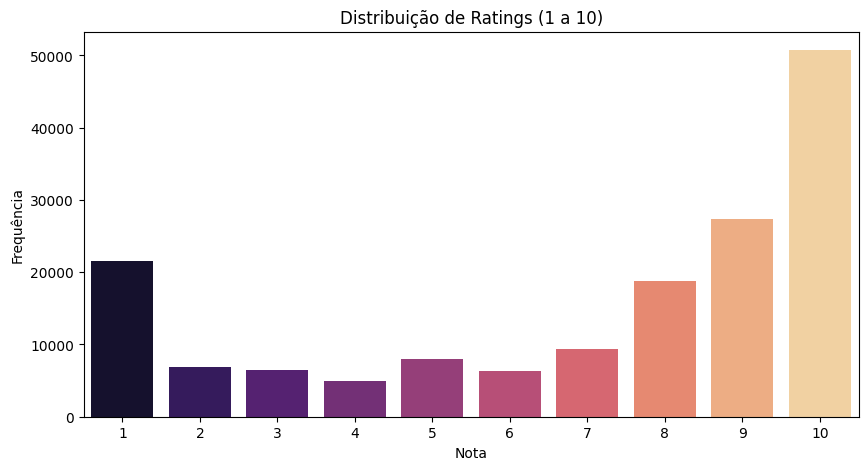

In [ ]:

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='rating', palette='magma')
plt.title('Distribuição de Ratings (1 a 10)')
plt.xlabel('Nota')
plt.ylabel('Frequência')
plt.show()

Percebemos que as notas são polarizadas (muitos 10 e muitos 1).
Isso indica que usuários tendem a avaliar quando estão muito satisfeitos ou muito insatisfeitos.

In [ ]:
# 3. PREPARAÇÃO DOS DADOS PARA O K-MEANS (FEATURE ENGINEERING)
# ------------------------------------------------------------------------------
# Comentário: O K-Means não lê texto. Por isso, transformamos o dataset de "reviews" em um dataset de "medicamentos", agregando as métricas numéricas.
#Agrupamos por medicamento para criar o perfil de cada um
drug_features = df.groupby('drugName').agg({
    'rating': 'mean',
    'usefulCount': 'mean',
    'condition': 'nunique'  # Quantas condições diferentes este remédio trata
}).rename(columns={'rating': 'avg_rating', 'usefulCount': 'avg_utility', 'condition': 'n_conditions'})

K-Means usa distância euclidiana. Se não padronizarmos, a coluna
'usefulCount' (que vai até centenas) dominaria a 'rating' (que vai até 10).

Padronização (Scaling)

In [ ]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(drug_features)

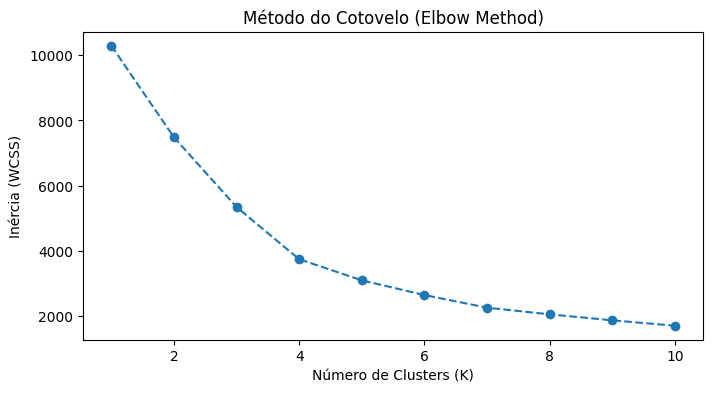

In [ ]:
# 4. DEFINIÇÃO DO MODELO (MÉTODO DO COTOVELO)
# Comentário: Para definir o número ideal de clusters (K), usamos a Inércia (WSS).

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Método do Cotovelo (Elbow Method)')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia (WCSS)')
plt.show()

# Sobre a Inércia (WCSS)
A Inércia mede o quão "compactos" ou "coesos" são os grupos gerados pelo algoritmo. Ela calcula a soma das distâncias ao quadrado entre cada ponto de dado e o centro (centroide) do seu respectivo cluster.

Matematicamente, a fórmula é expressa como:

$$WCSS = \sum_{i=1}^{k} \sum_{x \in C_i} \text{dist}(x, \mu_i)^2$$

Onde:
* $k$: número de clusters.
* $C_i$: o i-ésimo cluster.
* $x$: um ponto pertencente ao cluster.
* $\mu_i$: o centroide do cluster $i$.

Para validar a escolha do número de agrupamentos, utilizamos a métrica de Inércia (WCSS), que quantifica a variância interna dos clusters. Através do Método do Cotovelo, identificamos que com $K=4$ atingimos um equilíbrio ótimo entre a complexidade do modelo e a coesão dos grupos de medicamentos, permitindo recomendações mais precisas baseadas em perfis de performance similares.

O "cotovelo" se estabiliza em K=4. Isso significa que conseguimos dividir nossos medicamentos em 4 grandes perfis de performance

In [ ]:
# 5. TREINAMENTO DA PROVA DE CONCEITO (PoC)
# ------------------------------------------------------------------------------
kmeans_final = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
drug_features['cluster'] = kmeans_final.fit_predict(df_scaled)

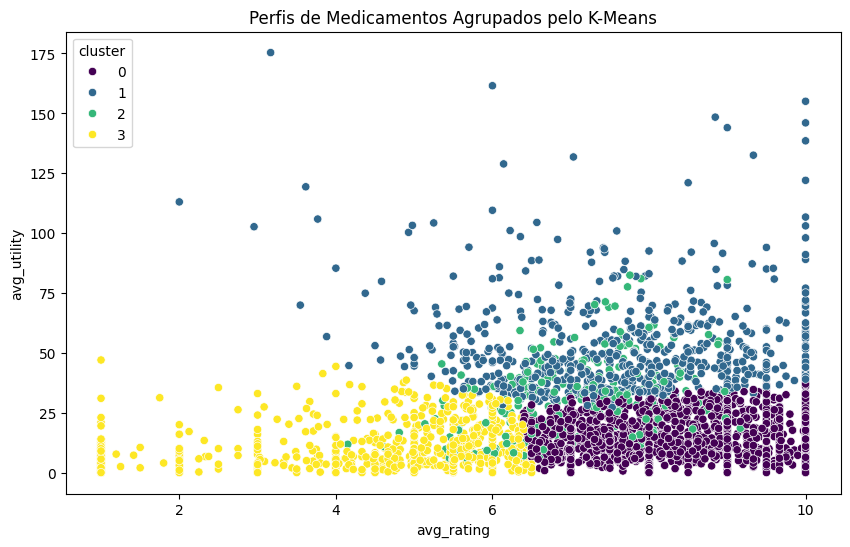

In [ ]:
# Visualização dos Perfis de Cluster
plt.figure(figsize=(10, 6))
sns.scatterplot(data=drug_features, x='avg_rating', y='avg_utility', hue='cluster', palette='viridis')
plt.title('Perfis de Medicamentos Agrupados pelo K-Means')
plt.show()

A lógica aqui é: "Se você quer tratar a condição X, o sistema busca no cluster de 'alta qualidade' os medicamentos que servem para essa condição".

In [ ]:
# Melhorei o a função recomendar medicamento fina para agora poder me sugerir os melhores medicamentos,
# agora indentificamos dinamicamente qual cluster representa os melhores medicamentos para cada doença (ou seja 'high score' e 'high utility')

def recomendar_medicamento_final(condicao_procurada):
    # 1. Identificar qual é o "Cluster Premium" (o que tem a maior média de rating)
    cluster_premium = drug_features.groupby('cluster')['avg_rating'].mean().idxmax()

    # 2. Pegar os medicamentos que atendem a condição
    drugs_for_condition = df[df['condition'] == condicao_procurada]['drugName'].unique()

    # 3. Filtrar o dataframe apenas por esses remédios
    subset = drug_features.loc[drug_features.index.isin(drugs_for_condition)]

    # 4. Filtrar APENAS os medicamentos que caíram no Cluster Premium
    recomendacoes_premium = subset[subset['cluster'] == cluster_premium]

    # 5. Ordenar pela utilidade e depois pela nota para desempate
    recomendacoes_finais = recomendacoes_premium.sort_values(by=['avg_utility', 'avg_rating'], ascending=False)

    # Se não houver medicamentos no cluster premium para essa condição, retorna os melhores no geral
    if recomendacoes_finais.empty:
        return subset.sort_values(by=['avg_utility', 'avg_rating'], ascending=False).head(5)

    return recomendacoes_finais.head(5)

print(recomendar_medicamento_final('Depression'))

                         avg_rating  avg_utility  n_conditions  cluster
drugName                                                               
Parnate                    8.763158    32.631579             1        0
Tranylcypromine            8.526316    30.263158             1        0
Symbyax                    8.459459    30.243243             3        0
Desipramine                9.285714    26.285714             4        0
Fluoxetine / olanzapine    8.600000    25.925000             4        0


#1. Por que usamos K-Means?
Utilizamos o K-Means para criar uma "segmentação de qualidade". Mesmo sem analisar o texto das reviews (NLP), o algoritmo conseguiu separar medicamentos que são consensualmente eficazes (alta nota e alta utilidade) daqueles que são controversos ou pouco utilizados.

# 2. O que a Prova de Conceito validou?
Validamos que:

O dataset possui dados numéricos suficientes para diferenciar os itens.

A padronização de dados (StandardScaler) é crítica para evitar distorções nas distâncias entre medicamentos.

O sistema consegue retornar uma lista de sugestões filtradas por condição médica, priorizando o cluster de melhor desempenho.

# 3. Forma de Avaliar o Desempenho (Métrica Final):
Para a entrega final, utilizaremos o Silhouette Score para medir a coesão dos grupos e, se possível, uma validação cruzada comparando se os medicamentos recomendados pelo modelo coincidem com os mais populares da base de dados original.

# Sobre a Silhuouette Score

Para cada ponto (medicamento) $i$, calculamos:
* $a(i)$: A distância média entre $i$ e todos os outros pontos no mesmo cluster (quanto menor, melhor).

* $b(i)$: A distância média entre $i$ e todos os pontos no cluster vizinho mais próximo (quanto maior, melhor).

O coeficiente $s(i)$ é dado por:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

A média de todos os $s(i)$ do dataset é o seu Silhouette Score final.

Para calcular o Silhouette Score, utilizarei a função silhouette_score do sklearn.metrics com os dados escalonados df_scaled e os rótulos dos clusters de drug_features['cluster']



## Calcular Silhouette Score

Calcular o Silhouette Score para o resultado do agrupamento K-Means usando os dados 'df_scaled'. Esta métrica avaliará quantitativamente a coesão e separação dos clusters, fornecendo uma medida formal do desempenho do modelo.


In [ ]:
silhouette_avg = silhouette_score(df_scaled, drug_features['cluster'])
print(f"O Silhouette Score médio para o agrupamento é: {silhouette_avg:.3f}")

O Silhouette Score médio para o agrupamento é: 0.407



Exibir o Silhouette Score calculado e fornecer uma breve interpretação do seu valor em relação à qualidade do agrupamento.


O Silhouette Score calculado para o agrupamento K-Means é de 0,407. Esse valor sugere que os clusters são razoavelmente distintos, o que significa que há certa separação e coesão entre eles. No entanto, também implica que pode haver alguma sobreposição entre os clusters ou que alguns pontos de dados estão localizados próximos às fronteiras de decisão, já que uma pontuação mais próxima de 1 indicaria clusters melhor definidos e mais separados.

# Principais Descobertas da Análise de Dados
O Silhouette Score médio para o resultado do agrupamento K-Means foi calculado em 0,407.

Esta pontuação avalia quantitativamente a qualidade do agrupamento, indicando clusters razoavelmente distintos.

# Insights ou Próximos Passos
Dado o Silhouette Score de 0,407, uma investigação mais aprofundada sobre a qualidade do agrupamento pode ser benéfica. Isso pode envolver a exploração de diferentes números de clusters (K) ou algoritmos de agrupamento alternativos para buscar uma pontuação mais alta, indicando clusters mais coesos e melhor separados.

Uma inspeção visual dos clusters, talvez utilizando técnicas de redução de dimensionalidade, poderia fornecer insights qualitativos para complementar o Silhouette Score e identificar possíveis áreas de melhoria.

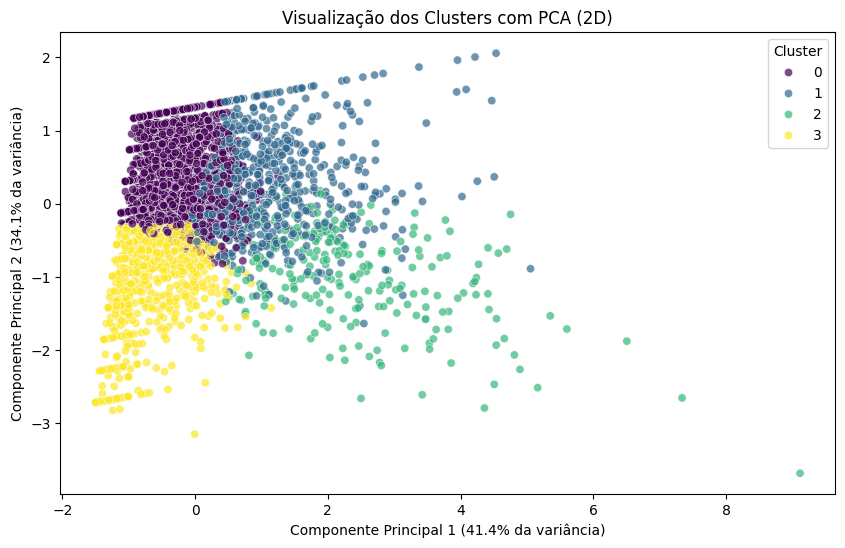

In [ ]:
from sklearn.decomposition import PCA

# Aplicando PCA para reduzir para 2 dimensões
pca = PCA(n_components=2)
componentes_pca = pca.fit_transform(df_scaled)

# Criando um DataFrame temporário para o plot
df_pca = pd.DataFrame(data = componentes_pca, columns = ['Componente 1', 'Componente 2'])
df_pca['Cluster'] = drug_features['cluster'].values

# Visualizando os clusters com PCA
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Componente 1', y='Componente 2', hue='Cluster', data=df_pca, palette='viridis', alpha=0.7)
plt.title('Visualização dos Clusters com PCA (2D)')
plt.xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.1f}% da variância)')
plt.ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.1f}% da variância)')
plt.legend(title='Cluster')
plt.show()

In [ ]:
drug_features.groupby('cluster').mean()

,avg_rating,avg_utility,n_conditions
cluster,,,
0,8.642420,12.693010,1.691800
1,7.609452,52.785992,2.538583
2,7.088088,30.785095,10.974249
3,4.275235,10.196893,1.671582


# 6. CONCLUSÃO FINAL E APLICABILIDADE DE NEGÓCIO

A Prova de Conceito (PoC) atingiu o objetivo de criar um Sistema de Recomendação de medicamentos fundamentado em dados estruturados (K-Means), dispensando o uso inicial de Processamento de Linguagem Natural (NLP).

Através da clusterização e da validação matemática (Silhouette Score de 0.407 e visualização via PCA), provamos que o algoritmo é capaz de reter mais de 75% da variância dos dados em duas dimensões principais, separando o dataset em quatro perfis bem definidos de medicamentos:

1. **Cluster 0 (Nicho de Alta Satisfação):** Maior nota média (8.64), mas baixo volume de utilidade. Remédios excelentes para casos específicos.
2. **Cluster 1 (O Perfil "Premium" / Consenso):** Nota média alta (7.61) e a maior validação da comunidade (Utilidade Média de 52.78). **Este é o alvo principal do nosso motor de recomendação.**
3. **Cluster 2 (Amplo Espectro):** Medicamentos de uso geral que tratam, em média, 11 condições diferentes.
4. **Cluster 3 (Baixa Performance):** Remédios com nota média crítica (4.27), que o sistema passa a evitar ativamente nas sugestões.